## Pipeline de Nettoyage des Données GDELT — Bénin

### Hackathon Isheero x DataCamp 2026 — Team 8

Ce notebook implémente le pipeline de nettoyage des données GDELT extraites depuis Google BigQuery pour le Bénin (code pays : BN).

#### Objectif : 
Ce notebook analyse les données GDELT du Bénin sous l'angle de la sécurité intérieure et de la criminalité organisée. L'objectif est de cartographier les menaces, d'identifier les réseaux criminels et les zones de trafic, tout en évaluant l'impact des dynamiques de déstabilisation transfrontalières.

### ÉTAPE 0 — Setup de l'environnement

Objectif : Préparer le notebook proprement avant toute analyse.

In [52]:
# Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
import plotly.express as px
from pathlib import Path
import plotly.graph_objects as go
from collections import Counter
import warnings
warnings.filterwarnings('ignore')


# Config affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
plt.rcParams['figure.figsize'] = (12, 5)

### ÉTAPE 1 — Chargement des données
Objectif : Charger le fichier et avoir une première idée de ce qu'on a.

In [53]:
# Chargement du dataset nettoyé
path = Path('../data/clean/bq-results-last-12-months-clean.csv')
df = pd.read_csv(path, low_memory=False)

benin_df = df[
    (df['ActionGeo_CountryCode'] == 'BN') |
    (df['Actor1CountryCode'] == 'BN') |
    (df['Actor2CountryCode'] == 'BN')
].copy()
print(f"Événements Bénin : {len(benin_df)}")

df['SQLDATE'] = pd.to_datetime(df['SQLDATE'], errors='coerce')
df['DATEADDED'] = pd.to_datetime(df['DATEADDED'], errors='coerce')
df['GoldsteinScale'] = pd.to_numeric(df['GoldsteinScale'], errors='coerce')
df['AvgTone'] = pd.to_numeric(df['AvgTone'], errors='coerce')
df['QuadClass'] = pd.to_numeric(df['QuadClass'], errors='coerce')

# Présentation initiale
print('Shape:', df.shape)
df.head()

Événements Bénin : 23859
Shape: (23859, 61)


,GLOBALEVENTID,SQLDATE,MonthYear,Year,FractionDate,Actor1Code,Actor1Name,Actor1CountryCode,Actor1KnownGroupCode,Actor1EthnicCode,Actor1Religion1Code,Actor1Religion2Code,Actor1Type1Code,Actor1Type2Code,Actor1Type3Code,Actor2Code,Actor2Name,Actor2CountryCode,Actor2KnownGroupCode,Actor2EthnicCode,Actor2Religion1Code,Actor2Religion2Code,Actor2Type1Code,Actor2Type2Code,Actor2Type3Code,IsRootEvent,EventCode,EventBaseCode,EventRootCode,QuadClass,GoldsteinScale,NumMentions,NumSources,NumArticles,AvgTone,Actor1Geo_Type,Actor1Geo_FullName,Actor1Geo_CountryCode,Actor1Geo_ADM1Code,Actor1Geo_ADM2Code,Actor1Geo_Lat,Actor1Geo_Long,Actor1Geo_FeatureID,Actor2Geo_Type,Actor2Geo_FullName,Actor2Geo_CountryCode,Actor2Geo_ADM1Code,Actor2Geo_ADM2Code,Actor2Geo_Lat,Actor2Geo_Long,Actor2Geo_FeatureID,ActionGeo_Type,ActionGeo_FullName,ActionGeo_CountryCode,ActionGeo_ADM1Code,ActionGeo_ADM2Code,ActionGeo_Lat,ActionGeo_Long,ActionGeo_FeatureID,DATEADDED,SOURCEURL
0,1281664740,2025-12-31,202512,2025,2025.989,BEN,BENIN,BEN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,43,43,4,1,2.8,10,1,10,-1.095890,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 11:00:00,https://www.rewmi.com/koulibaly-la-rdc-va-faire-des-ravages-jen-suis-convaincu/
1,1281675550,2025-12-31,202512,2025,2025.989,MIL,COMMANDANT,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,MIL,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,10,10,1,1,0.0,5,1,5,-9.577465,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:00:00,https://dailypost.ng/2025/12/31/nscdc-arrests-suspected-oil-installation-van...
2,1281675733,2025-12-31,202512,2025,2025.989,SPY,OPERATIVE,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,SPY,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,1712,171,17,4,-9.2,10,1,10,-9.577465,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:00:00,https://dailypost.ng/2025/12/31/nscdc-arrests-suspected-oil-installation-van...
3,1281680079,2025-12-31,202512,2025,2025.989,IGOUNO,THE UN,UNKNOWN,UNO,UNKNOWN,UNKNOWN,UNKNOWN,IGO,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0,12,12,1,1,-0.4,1,1,1,-7.817970,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 13:45:00,https://www.aa.com.tr/en/africa/year-ender-africa-in-2025-2-military-coups-a...
4,1281667763,2025-12-31,202512,2025,2025.989,ELI,ACTOR,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,ELI,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,0,20,20,2,1,3.0,20,2,20,-3.197057,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,0,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,UNKNOWN,1,Benin,BN,BN,UNKNOWN,9.5,2.25,BN,2025-12-31 11:30:00,https://www.leral.net/560-MILLIARDS-MOBILISES-SUR-LE-MARCHE-Succes-technique...


#### 1. Comprendre le dataset
Cette section vérifie les dimensions, les valeurs manquantes, les types de variables et prépare le terrain pour l'analyse exploratoire.

In [54]:
print('Colonnes principales :', len(df.columns))
print('Années couvertes :', sorted(df['Year'].dropna().unique().astype(int)))
print('\nTypes de variables :')
print(df.dtypes.value_counts())

print('\nValeurs manquantes par colonne (top 20) :')
print(df.isna().sum().sort_values(ascending=False).head(20))

print("Doublons sur GLOBALEVENTID :", df['GLOBALEVENTID'].duplicated().sum())
df = df.drop_duplicates(subset='GLOBALEVENTID')

Colonnes principales : 61
Années couvertes : [np.int64(2025)]

Types de variables :
str               40
int64             14
float64            5
datetime64[us]     2
Name: count, dtype: int64

Valeurs manquantes par colonne (top 20) :
GLOBALEVENTID           0
SQLDATE                 0
MonthYear               0
Year                    0
FractionDate            0
Actor1Code              0
Actor1Name              0
Actor1CountryCode       0
Actor1KnownGroupCode    0
Actor1EthnicCode        0
Actor1Religion1Code     0
Actor1Religion2Code     0
Actor1Type1Code         0
Actor1Type2Code         0
Actor1Type3Code         0
Actor2Code              0
Actor2Name              0
Actor2CountryCode       0
Actor2KnownGroupCode    0
Actor2EthnicCode        0
dtype: int64
Doublons sur GLOBALEVENTID : 0


Normalisation de la colonne 'GoldsteinScale'& AvgTone

In [55]:
for col, low, high in [("GoldsteinScale", -10.0, 10.0), ("AvgTone", None, None)]:
    df[col] = pd.to_numeric(df[col], errors="coerce")
    if low  is not None: df[col] = df[col].clip(lower=low)
    if high is not None: df[col] = df[col].clip(upper=high)
    median     = df[col].median()
    nans       = df[col].isna().sum()
    df[col]    = df[col].fillna(median)
    print(f"{col:20s}  NaN imputés={nans}  médiane={median:.4f}")

df[["GoldsteinScale", "AvgTone"]].describe()

GoldsteinScale        NaN imputés=0  médiane=1.9000
AvgTone               NaN imputés=0  médiane=-1.3725


,GoldsteinScale,AvgTone
count,23859.000000,23859.000000
mean,0.548326,-1.494268
std,4.591191,4.566204
min,-10.000000,-18.518519
25%,-2.000000,-4.761905
50%,1.900000,-1.372549
75%,3.400000,1.836735
max,10.000000,19.480519


### ÉTAPE 3 — Analyse Exploratoire Générale (Vue d'ensemble)
Objectif : Identifier tous les insights

3.1 — Distribution temporelle - Nombre d'événement par mois

<Axes: title={'center': "Nombre d'événements par mois — Bénin"}, xlabel='SQLDATE'>

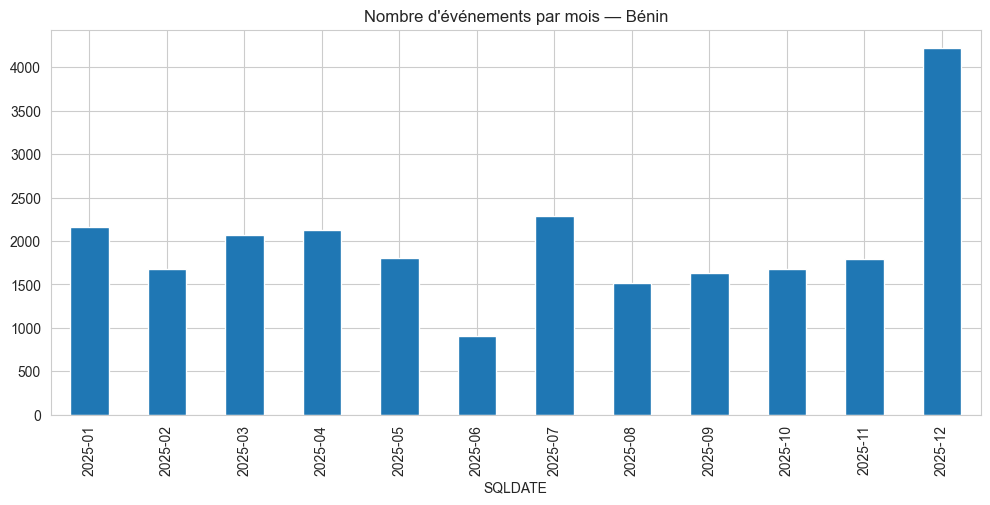

In [56]:
events_by_month = df.groupby(df['SQLDATE'].dt.to_period('M')).size()
events_by_month.plot(kind='bar', title='Nombre d\'événements par mois — Bénin')

Observation : 
Le graphique montre une variation mensuelle du nombre d'événements au Bénin, avec un pic marqué en décembre 2025 (4221 événements), suggérant une période d'activité intense. A quoi corresponde t'il exactement ? des crises, l'élection ...

3.2 — Répartition par QuadClass (nature des événements)

<Axes: title={'center': "Types d'événements au Bénin"}>

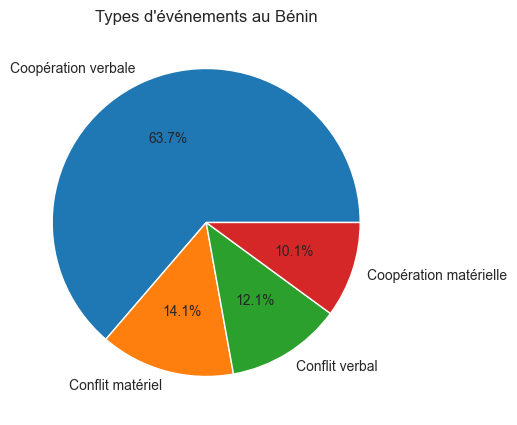

In [57]:
quad_labels = {1: 'Coopération verbale', 2: 'Coopération matérielle',
               3: 'Conflit verbal', 4: 'Conflit matériel'}
df['QuadClass_Label'] = df['QuadClass'].map(quad_labels)
df['QuadClass_Label'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    title='Types d\'événements au Bénin')

Observation : On voit que les événements liés au Bénin sont majoritairement de nature verbale (coopération ou conflit), avec une très faible proportion d'événements matériels. Cela suggère que les interactions impliquant le Bénin dans ce dataset sont principalement de nature diplomatique ou médiatique, plutôt que des actions physiques ou militaires.

3.3 — Nombre d'événements par type d'évenement (QuadClass)

Text(0, 0.5, "Nombre d'événements")

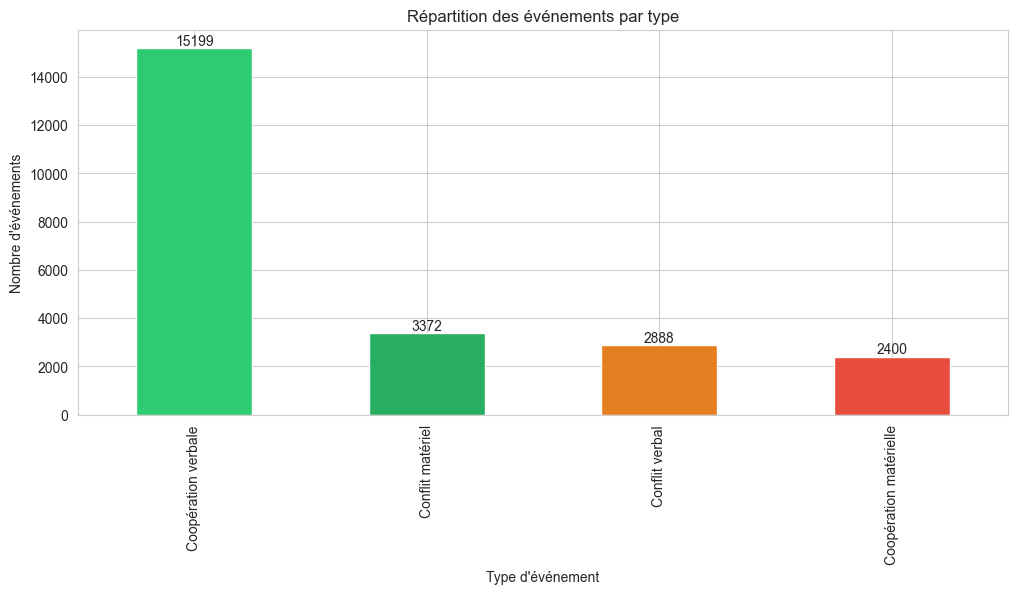

In [58]:
colors = ['#2ecc71', '#27ae60', '#e67e22', '#e74c3c']
quad_counts = df['QuadClass_Label'].value_counts()
quad_counts.plot(kind='bar', title='Répartition des événements par type', color=colors)

# Ajouter les nombres au-dessus de chaque barre
ax = plt.gca()
for i, count in enumerate(quad_counts):
    ax.text(i, count + 5, str(count), ha='center', va='bottom', fontsize=10)    

plt.xlabel('Type d\'événement')
plt.ylabel('Nombre d\'événements')


Observation : Ce graphique en barres illustre la répartition des événements au Bénin selon leur nature (QuadClass). La catégorie "Coopération verbale" domine largement avec plus de 15 119 événements, suivie par "Conflit matériel" (environ 3 372), "Conflit verbal" (2 888) et "Coopération matérielle" (2 400). Cela confirme que les événements impliquant le Bénin sont principalement de nature diplomatique et verbale, avec une minorité d'actions matérielles, soulignant un contexte plus axé sur les relations internationales que sur les conflits armés directs.

3.4 la repartition des événements par mois et par type d'événement (QuadClass)

<Axes: title={'center': 'Événements par mois et type'}, xlabel='SQLDATE'>

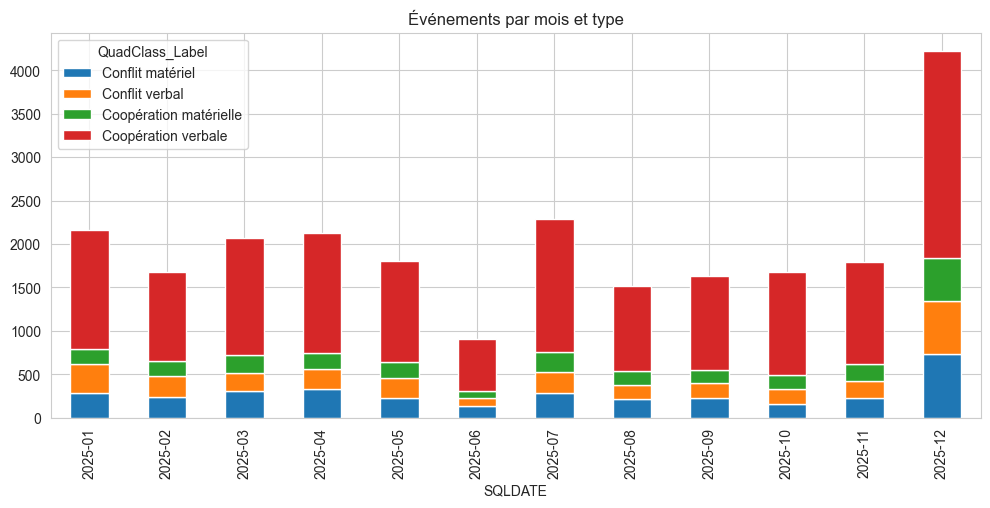

In [59]:
events_by_month_quad = df.groupby([df['SQLDATE'].dt.to_period('M'), 'QuadClass_Label']).size().unstack(fill_value=0)
events_by_month_quad.plot(kind='bar', stacked=True, title='Événements par mois et type')

On observe un pic d'activité exceptionnel en décembre 2025, où toutes les catégories — incluant les conflits matériels et verbaux — atteignent leur niveau maximal, suggérant une période de forte instabilité ou d'interactions intenses.

3.5 Le ton médiatique moyen par mois (AvgTone)

Text(0, 0.5, 'Tonalité moyenne (AvgTone)')

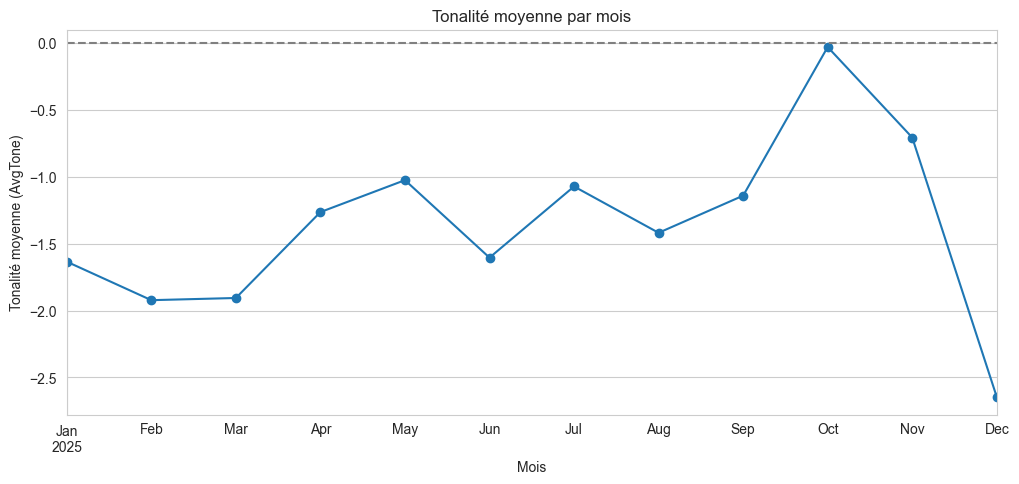

In [61]:
avg_tone_by_month = df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone'].mean()
avg_tone_by_month.plot(kind='line', marker='o', title='Tonalité moyenne par mois')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Mois')
plt.ylabel('Tonalité moyenne (AvgTone)')

La courbe évolue quasi exclusivement en dessous de la ligne du zéro (pointillé), ce qui indique une tonalité majoritairement négative tout au long de l'année.

On observe une tendance à la hausse (amélioration du sentiment) à partir d'avril, atteignant son point le plus proche de la neutralité en octobre (presque 0,0).

Le fait le plus marquant est l'effondrement drastique en décembre, où la tonalité chute à son niveau le plus bas de l'année (environ -2,7).

3.6 Le ton médiatique mensuel (AvgTone)

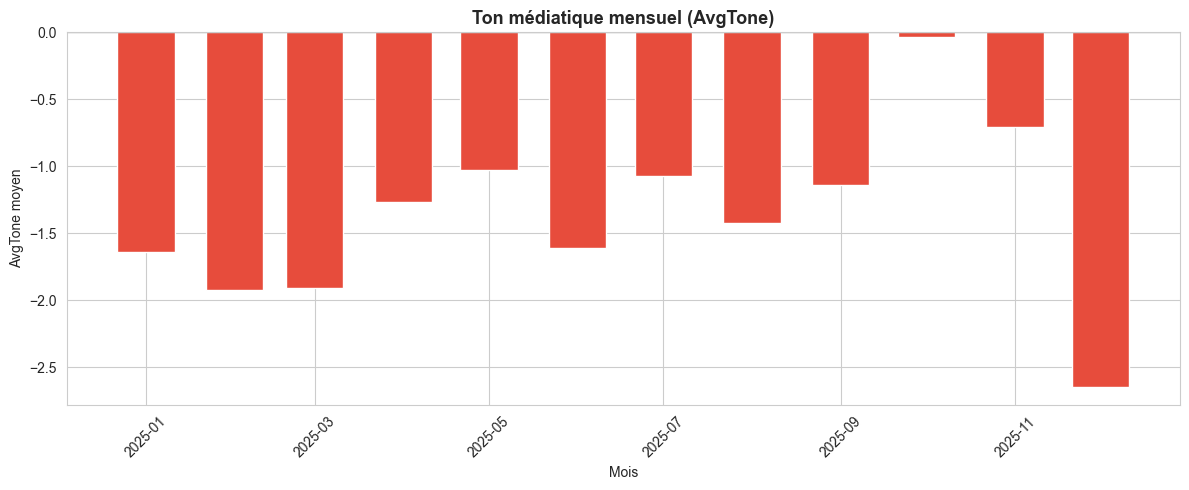

In [62]:
monthly_tone = (
    df.groupby(df['SQLDATE'].dt.to_period('M'))['AvgTone']
    .mean().reset_index()
)
monthly_tone['SQLDATE'] = monthly_tone['SQLDATE'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.bar(monthly_tone['SQLDATE'], monthly_tone['AvgTone'],
       color=['#e74c3c' if v < 0 else '#2ecc71' for v in monthly_tone['AvgTone']], width=20)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Ton médiatique mensuel (AvgTone)', fontsize=13, fontweight='bold')
ax.set_xlabel('Mois')
ax.set_ylabel('AvgTone moyen')
#ax.xaxis.set_major_formatter(mates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../data/clean/avgtone_mensuel.png', dpi=150)
plt.show()

3.7 — Score de Goldstein dans le temps

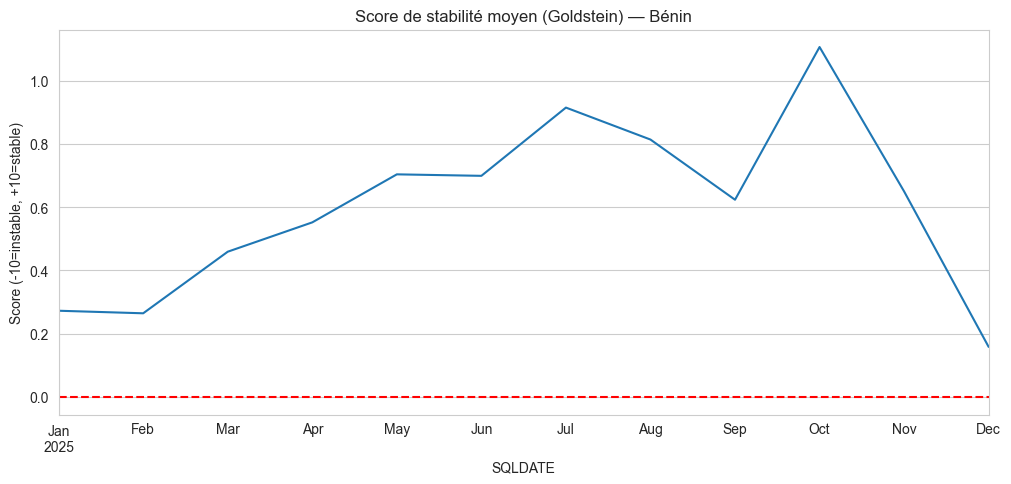

In [63]:
monthly_goldstein = df.groupby(df['SQLDATE'].dt.to_period('M'))['GoldsteinScale'].mean()
monthly_goldstein.plot(title='Score de stabilité moyen (Goldstein) — Bénin',
                       ylabel='Score (-10=instable, +10=stable)')
plt.axhline(0, color='red', linestyle='--')

- Entre janvier et février, le score est stable mais bas (environ +0,3).
- À partir de mars, on observe une hausse continue de la stabilité.
- La stabilité atteint son maximum en octobre, avec un score dépassant +1,1. C'est le moment de l'année où les interactions ont été les plus "stables" ou coopératives.

En résumé le Bénin a connu une année 2025 marquée par une montée en puissance de la stabilité sociale/politique durant les trois premiers trimestres, mais cette dynamique s'est brisée net lors des deux derniers mois de l'année.

3.8 — Top acteurs impliqués

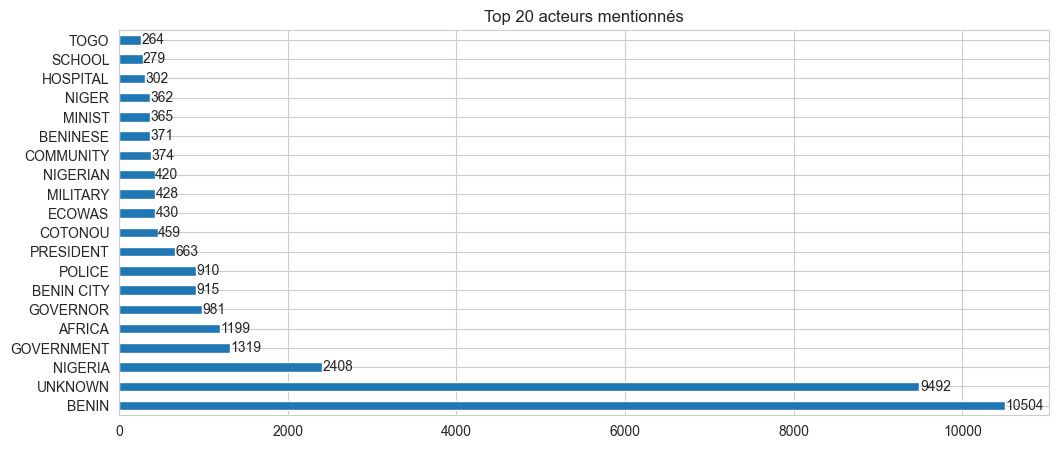

In [64]:
top_actors = pd.concat([df['Actor1Name'], df['Actor2Name']]).value_counts().head(20)
top_actors.plot(kind='barh', title='Top 20 acteurs mentionnés')

# Ajouter les nombres au-dessus de chaque barre
ax = plt.gca()
for i, count in enumerate(top_actors):
    ax.text(count + 5, i, str(count), ha='left', va='center', fontsize=10)
  

Observation : 
Les évènements sont massivement concentrées sur le Benin et le Nigeria. Les mentions sont dominées par les entités étatiques (Gouvernement, Police) et des acteurs régionaux comme la CEDEAO.
Il existe un volume très élevé de données non identifiées (UNKNOWN), ce qui représente un défi pour une catégorisation exhaustive des acteurs.

3.9 — Top EventCodes (types d'événements CAMEO)

,EventCode,Nombre,Label
0,010,2583,"Make statement, not specified below"
1,051,2310,Praise or endorse
2,042,2042,Make a visit
3,043,2002,Host a visit
4,020,1454,"Appeal, not specified below"
5,040,1157,"Consult, not specified below"
6,173,942,"Arrest, detain, or charge with legal action"
7,190,918,"Use conventional military force, not specified below"
8,111,494,Criticize or denounce
9,046,483,Engage in negotiation


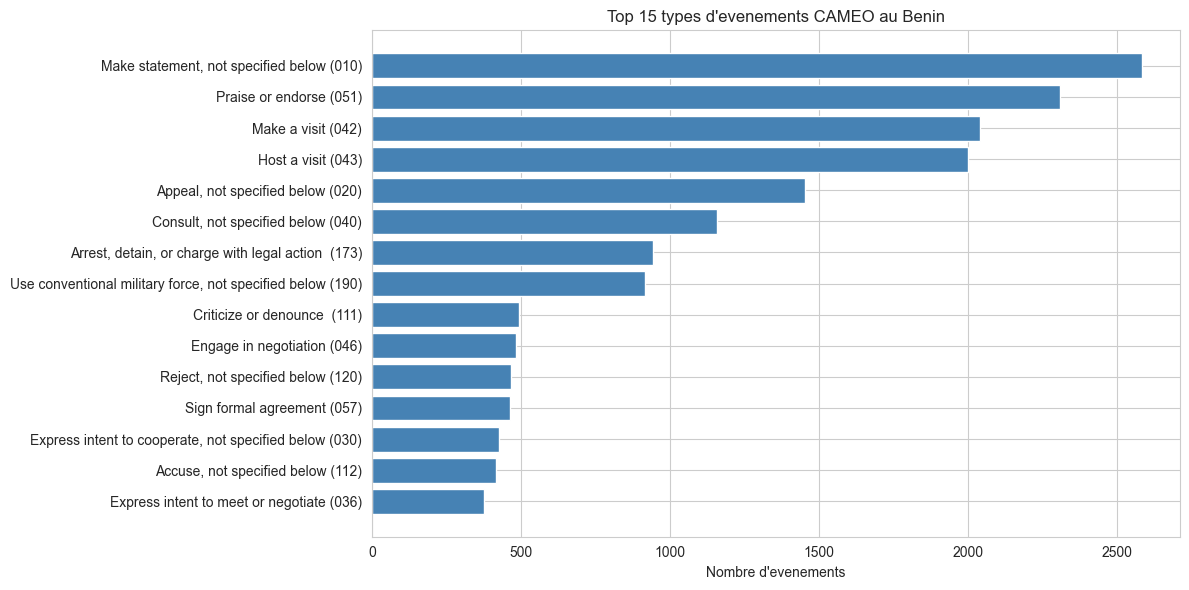

In [65]:
# Charger le dictionnaire CAMEO complet (codes detailles)
cameo_ref = pd.read_csv('../old-files/CAMEO.eventcodes.txt', sep='	', dtype=str)
cameo_ref = cameo_ref[cameo_ref['CAMEOEVENTCODE'].str.len() > 2].copy()
cameo_ref['CAMEOEVENTCODE'] = cameo_ref['CAMEOEVENTCODE'].str.zfill(3)
cameo_dict = cameo_ref.set_index('CAMEOEVENTCODE')['EVENTDESCRIPTION'].to_dict()

# EventCode est numerique dans df : on le remet au format CAMEO a 3 chiffres (010, 040, 173...)
event_codes = df['EventCode'].astype('Int64').astype(str).str.zfill(3)

# Compter les occurrences et ajouter les labels lisibles
top_events = event_codes.value_counts().head(15).reset_index()
top_events.columns = ['EventCode', 'Nombre']
top_events['Label'] = top_events['EventCode'].map(cameo_dict).fillna('Code CAMEO inconnu')

display(top_events)

plt.figure(figsize=(12, 6))
plt.barh(top_events['Label'] + ' (' + top_events['EventCode'] + ')',
         top_events['Nombre'],
         color='steelblue')
plt.xlabel("Nombre d'evenements")
plt.title("Top 15 types d'evenements CAMEO au Benin")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

3.10 Tonalité médiatique (AvgTone)


Text(0.5, 1.0, 'Distribution de la tonalité des articles sur le Bénin')

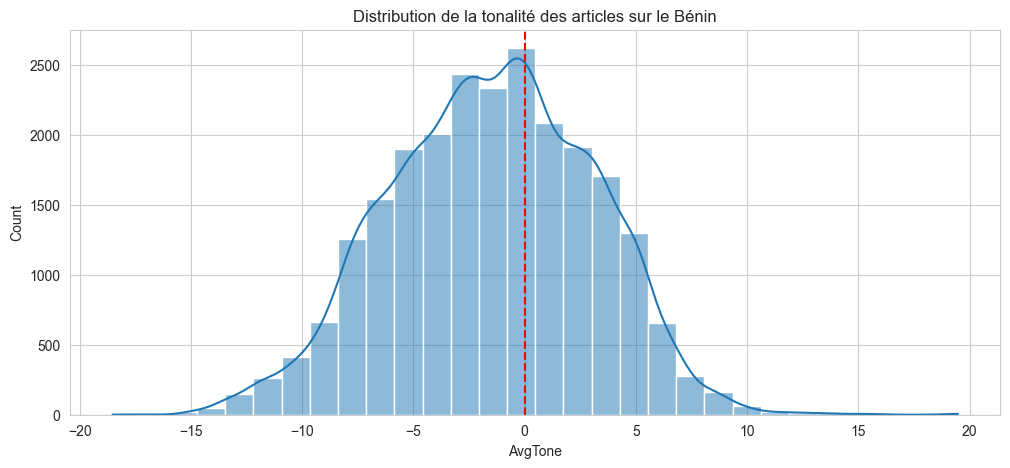

In [66]:
sns.histplot(df['AvgTone'], bins=30, kde=True)
plt.axvline(0, color='red', linestyle='--')
plt.title('Distribution de la tonalité des articles sur le Bénin')

- Les données suivent une forme de "cloche" centrée autour de zéro, ce qui indique que la majorité des articles ont une tonalité relativement neutre.
- Le pic de la distribution (le mode) semble se situer légèrement à gauche de la ligne rouge pointillée (0,0). Cela suggère qu'il y a un volume un peu plus important d'articles à connotation négative par rapport aux articles positifs.
- Étendue des valeurs : La tonalité varie principalement entre -10 et +10. Les articles extrêmement négatifs (vers -15) ou extrêmement positifs (vers +15) sont très rares (valeurs aberrantes).
- Volume de données : Le sommet de la courbe atteint plus de 2 500 articles, ce qui montre une base de données solide pour cette analyse de sentiment.

En résumé, la couverture médiatique du Bénin est globalement équilibrée, bien qu'elle penche légèrement vers une tonalité critique ou négative.


3.11 — Carte géographique des événements

In [59]:
fig = px.scatter_mapbox(df.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long']),
    lat='ActionGeo_Lat', lon='ActionGeo_Long',
    hover_name='ActionGeo_FullName',
    color='QuadClass_Label',
    size='NumMentions',
    mapbox_style='carto-positron',
    title='Géolocalisation des événements au Bénin')
fig.show()

Observation : 
La carte montre une double dynamique. D’une part, les événements sont fortement représentés dans plusieurs villes importantes du Sud et du Centre, comme Porto-Novo, Ouidah, Abomey, Lokossa ou Parakou, ce qui peut refléter à la fois la concentration urbaine et la couverture médiatique. 

D’autre part, les événements liés à l’insécurité ressortent davantage dans le Nord du Bénin, notamment autour de Porga, Malanville, Kandi, Karimama, Alibori, Tanguiéta et Natitingou. Cette distribution confirme une concentration plus marquée des événements sécuritaires dans les zones frontalières, proches du Niger, du Burkina Faso et du Nigeria.


3.12 Vue d'ensemble des événements liés à l'insécurité

In [67]:
df_conflict  = df[df['QuadClass'].isin([3, 4])].copy()
df_high_risk = df[df['GoldsteinScale'] < -5].copy()
total        = len(df)

print('═' * 50)
print('  VUE D\'ENSEMBLE AU NIVEAU SÉCURITAIRE')
print('═' * 50)
print(f'  Total événements        : {total:,}')
print(f'  Événements conflictuels : {len(df_conflict):,}  ({len(df_conflict)/total*100:.1f}%)')
print(f'  Haut risque (GS < -5)   : {len(df_high_risk):,}  ({len(df_high_risk)/total*100:.1f}%)')
print(f'  GoldsteinScale moyen    : {df["GoldsteinScale"].mean():.3f}')
print(f'  AvgTone moyen           : {df["AvgTone"].mean():.3f}')

══════════════════════════════════════════════════
  VUE D'ENSEMBLE AU NIVEAU SÉCURITAIRE
══════════════════════════════════════════════════
  Total événements        : 23,859
  Événements conflictuels : 6,260  (26.2%)
  Haut risque (GS < -5)   : 2,561  (10.7%)
  GoldsteinScale moyen    : 0.548
  AvgTone moyen           : -1.494


#### ÉTAPE 4 — Focus Sécurité & Criminalité Organisée
Objectif : Après avoir montré le panorama général, zoomons sur l'angle retenu en le justifiant par les données.

L'analyse générale révèle que 26.2% des événements sont de nature conflictuelle, avec un score Goldstein moyen de 0. 548 sur les derniers mois. On observe une concentration géographique dans le nord du pays et une présence marquée d'acteurs non-étatiques. Ces signaux nous orientent naturellement vers l'analyse de la sécurité intérieure."

In [68]:


# 1. Préparation de la colonne de codes au format CAMEO (3 chiffres)
# On le fait sur le DataFrame principal pour faciliter le groupby
df['EventCode_Str'] = df['EventCode'].astype('Int64').astype(str).str.zfill(3)

# 2. Agrégation mensuelle
summary = df.groupby(df['SQLDATE'].dt.to_period('M')).agg(
    total_evenements = ('GLOBALEVENTID', 'count'),
    # On récupère le code le plus fréquent (mode)
    code_dominant    = ('EventCode_Str', lambda x: x.value_counts().idxmax() if not x.empty else None),
    conflits         = ('QuadClass', lambda x: x.isin([3, 4]).sum()),
    goldstein_moy    = ('GoldsteinScale', 'mean'),
    avgtone_moy      = ('AvgTone', 'mean'),
).round(3)

# 3. Traduction du code dominant en Label via votre cameo_dict
summary['evenement_dominant'] = summary['code_dominant'].map(cameo_dict).fillna('Code inconnu')

# 4. Calcul du taux et organisation finale
summary['taux_conflit_%'] = (summary['conflits'] / summary['total_evenements'] * 100).round(1)

# Sélection des colonnes pour le rapport final
cols_finales = ['total_evenements', 'evenement_dominant', 'conflits', 'taux_conflit_%', 'avgtone_moy']

print(summary[cols_finales].to_string())

         total_evenements                   evenement_dominant  conflits  taux_conflit_%  avgtone_moy
SQLDATE                                                                                              
2025-01              2163  Make statement, not specified below       614            28.4       -1.635
2025-02              1673                         Make a visit       485            29.0       -1.923
2025-03              2067  Make statement, not specified below       515            24.9       -1.907
2025-04              2125  Make statement, not specified below       562            26.4       -1.265
2025-05              1807  Make statement, not specified below       462            25.6       -1.026
2025-06               908                    Praise or endorse       226            24.9       -1.605
2025-07              2284                         Make a visit       524            22.9       -1.074
2025-08              1516  Make statement, not specified below       382          

4.1 — Filtrage des événements de sécurité - Nombre de code de conflit 

In [69]:
import re

# Liste de mots-clés liés à l'insécurité
mots_cles = ['fight', 'assault', 'kill', 'arrest', 'protest', 'riot', 'military', 'force', 'weapon', 'attack', 'bomb']

# Création d'un sous-dictionnaire filtré
# On cherche si l'un des mots-clés est présent dans la description (en minuscules)
conflit_dict = {
    code: desc for code, desc in cameo_dict.items() 
    if any(mot in desc.lower() for mot in mots_cles) or code.startswith(('18', '19', '20'))
}

# Transformation en DataFrame pour une lecture propre
df_codes_securite = pd.DataFrame(list(conflit_dict.items()), columns=['Code', 'Description'])

print(f"Nombre de codes de conflit identifiés : {len(df_codes_securite)}")
print(df_codes_securite.sort_values('Code').head(20))

Nombre de codes de conflit identifiés : 63
    Code  \
0   0212   
1   0232   
2   0234   
3   0256   
4   0332   
5   0334   
6   0356   
7    072   
8    074   
9    087   
10  0872   
11  0873   
12   093   
13  1012   
14  1032   
15  1034   
16  1056   
17  1212   
18  1222   
19  1224   

                                                                Description  
0                                           Appeal for military cooperation  
1                                                   Appeal for military aid  
2                            Appeal for military protection or peacekeeping  
3                           Appeal for de-escalation of military engagement  
4                                    Express intent to provide military aid  
5             Express intent to provide military protection or peacekeeping  
6                        Express intent to de-escalate military engagement   
7                                                      Provide military aid  
8 

4.2 Analyse des pics d'incidents sécuritaire

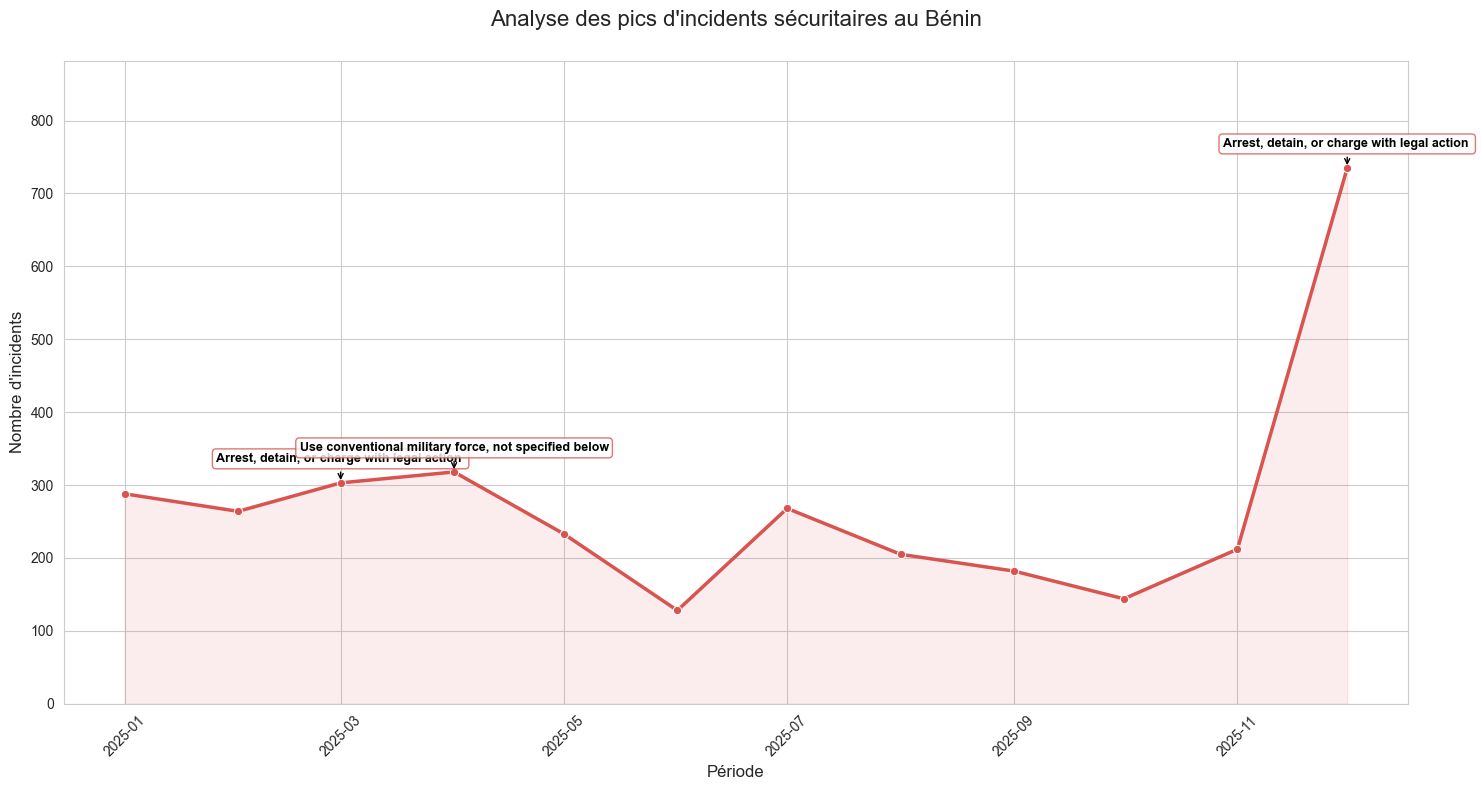

In [70]:
# 1. Filtrage préalable : on ne garde que les incidents de sécurité
conflict_material = df[df['QuadClass'] == 4].copy()
df_secu = df[df['EventCode_Str'].isin(df_codes_securite['Code'])].copy()

# 2. Agrégation mensuelle pour la courbe et pour trouver l'événement dominant
timeline_secu = df_secu.groupby(df_secu['SQLDATE'].dt.to_period('M')).agg(
    nb_incidents = ('GLOBALEVENTID', 'count'),
    top_code     = ('EventCode_Str', lambda x: x.value_counts().idxmax())
).reset_index()

timeline_secu['SQLDATE_TS'] = timeline_secu['SQLDATE'].dt.to_timestamp()
timeline_secu['label_dominant'] = timeline_secu['top_code'].map(cameo_dict)

# 3. Création du graphique
plt.figure(figsize=(15, 8))
sns.set_style("whitegrid")

# La courbe
line = sns.lineplot(data=timeline_secu, x='SQLDATE_TS', y='nb_incidents', 
                    marker='o', color='#d9534f', linewidth=2.5)
plt.fill_between(timeline_secu['SQLDATE_TS'], timeline_secu['nb_incidents'], color='#d9534f', alpha=0.1)

# 4. AJOUT DES ANNOTATIONS SUR LES PICS
# On définit un seuil pour considérer que c'est un pic (ex: > 250 incidents ou les 3 plus hauts)
seuil_pic = timeline_secu['nb_incidents'].quantile(0.75) 

for i, row in timeline_secu.iterrows():
    if row['nb_incidents'] >= seuil_pic:
        plt.annotate(
            row['label_dominant'], 
            xy=(row['SQLDATE_TS'], row['nb_incidents']),
            xytext=(0, 15), # Décale le texte de 15 points au-dessus du point
            textcoords='offset points',
            ha='center',
            fontsize=9,
            fontweight='bold',
            color='black',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='#d9534f', alpha=0.8),
            arrowprops=dict(arrowstyle='->', color='black')
        )

# Design final
plt.title('Analyse des pics d\'incidents sécuritaires au Bénin', fontsize=16, pad=25)
plt.ylabel('Nombre d\'incidents', fontsize=12)
plt.xlabel('Période', fontsize=12)
plt.xticks(rotation=45)
plt.ylim(0, timeline_secu['nb_incidents'].max() * 1.2) # Marge en haut pour les étiquettes

plt.tight_layout()
plt.show()

L'insécurité au Bénin, sur cette période, semble se manifester par des vagues de tensions gérées principalement par le système judiciaire et policier (arrestations), avec un recours ponctuel à la force militaire. Le mois de décembre 2025 constitue le point de rupture statistique qui mériterait une analyse contextuelle approfondie pour en comprendre les causes (contexte politique, opérations spéciales, etc.).

4.3 Taux d'incidents de sécurité par mois 

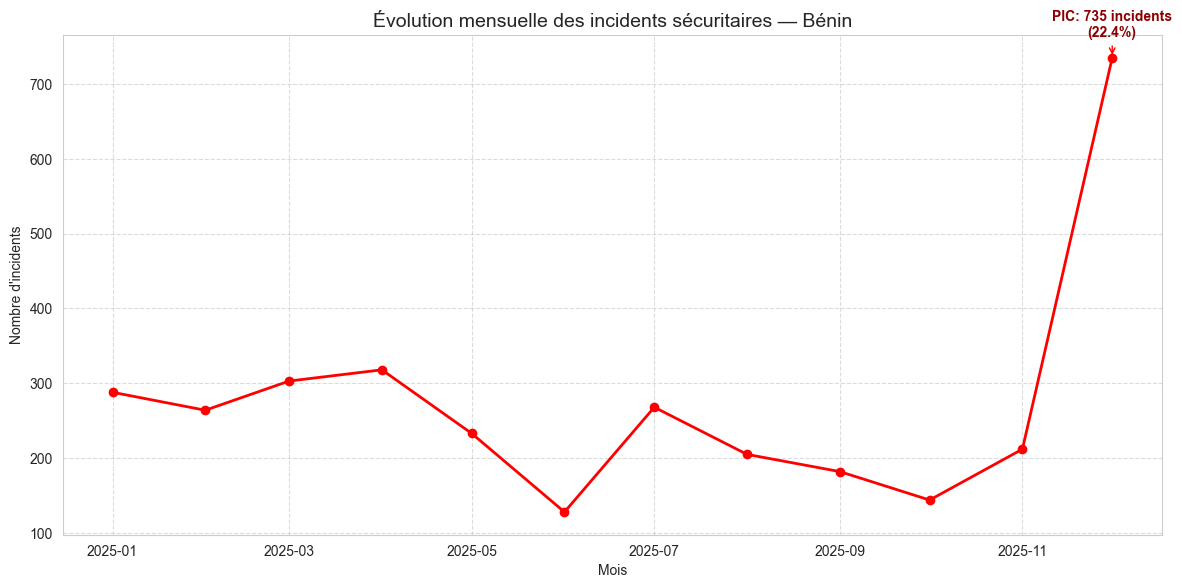

In [78]:
import matplotlib.pyplot as plt

# 1. Préparation des données
# On transforme la série en DataFrame pour manipuler plus facilement les colonnes
security_df = security_monthly.to_frame(name='Nombre').reset_index()
security_df['SQLDATE'] = security_df['SQLDATE'].dt.to_timestamp()

# Calcul du pourcentage par rapport au total annuel
total_incidents = security_df['Nombre'].sum()
security_df['Pourcentage'] = (security_df['Nombre'] / total_incidents * 100).round(1)

# 2. Identification des pics (Max global ou Max locaux)
# Ici, nous allons annoter le point le plus haut du graphique
valeur_max = security_df['Nombre'].max()
pics = security_df[security_df['Nombre'] == valeur_max]

# 3. Tracé du graphique
plt.figure(figsize=(12, 6))
plt.plot(security_df['SQLDATE'], security_df['Nombre'], marker='o', color='red', linewidth=2)

# 4. Ajout des annotations sur les pics
for i, row in pics.iterrows():
    plt.annotate(
        f"PIC: {row['Nombre']} incidents\n({row['Pourcentage']}%)", # Texte du libellé
        xy=(row['SQLDATE'], row['Nombre']), # Position du point
        xytext=(0, 15), # Décalage du texte (15 pixels au-dessus)
        textcoords='offset points',
        ha='center',
        fontsize=10,
        fontweight='bold',
        color='darkred',
        arrowprops=dict(arrowstyle='->', color='red') # Petite flèche pointant le pic
    )

# Configuration finale
plt.title('Évolution mensuelle des incidents sécuritaires — Bénin', fontsize=14)
plt.xlabel('Mois')
plt.ylabel('Nombre d\'incidents')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()

plt.show()

Le graphique présente une dynamique en trois phases distinctes sur la période allant dejanvier 2025 à decembre 2025 :

- De janvier à novembre, le nombre d'incidents fluctue de manière modérée, restant généralement compris entre 150 et 320 incidents par mois.
- On observe des baisses notables en juin (point le plus bas avant la fin d'année) et en octobre.
- Le fait le plus frappant est la hausse exponentielle en décembre, où le nombre d'incidents grimpe en flèche pour atteindre un pic de plus de 700.
- Ce pic d'incidents en décembre explique parfaitement la chute brutale de la tonalité (sentiments négatifs) observée sur le premier graphique
- Il confirme également la dégradation soudaine du score de stabilité Goldstein à la même période

L'année 2025 a été marquée par une gestion sécuritaire sous contrôle jusqu'en novembre, suivie d'une crise majeure ou d'un événement déstabilisateur intense en décembre qui a radicalement impacté tous les indicateurs (volume d'incidents, tonalité médiatique et stabilité politique).

4.4 Acteurs impliqués dans les conflits

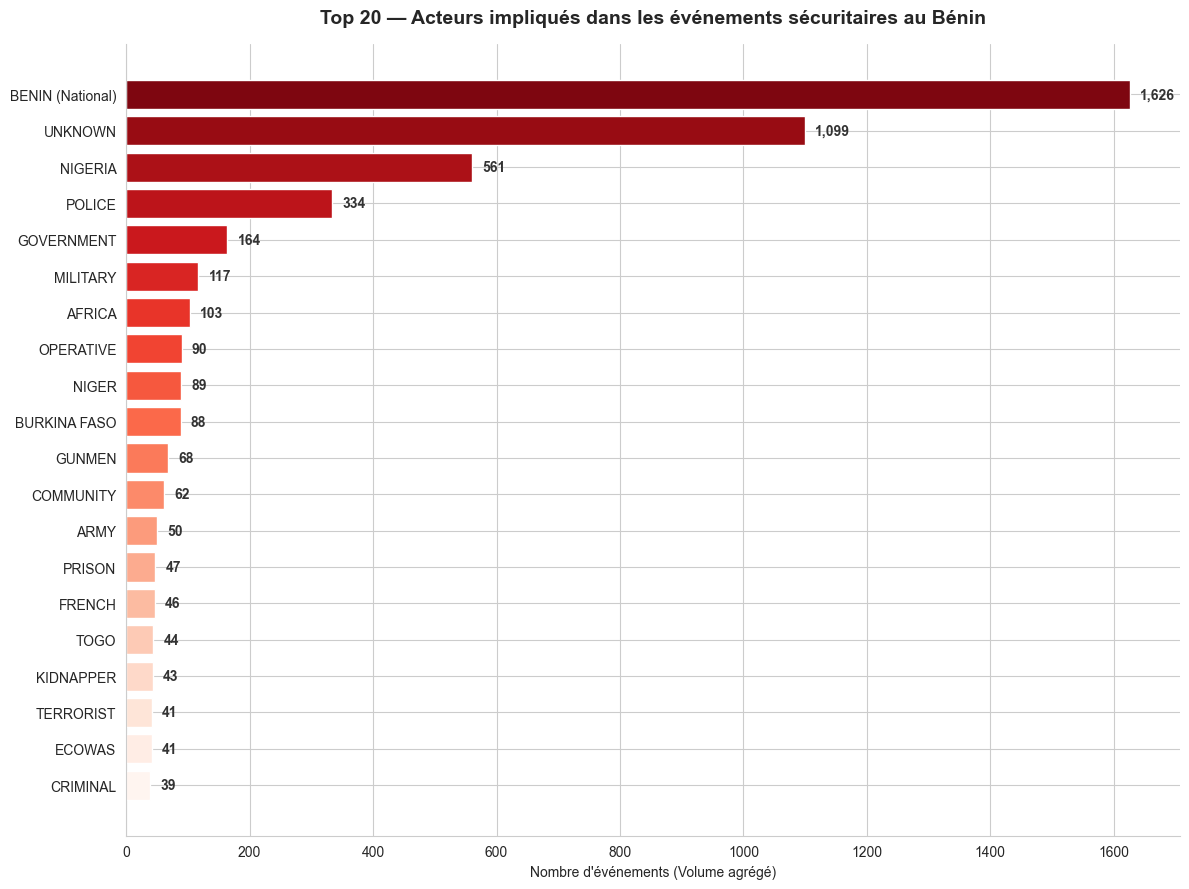

In [79]:
# 1. Concaténation et nettoyage
all_actors = pd.concat([df_secu['Actor1Name'], df_secu['Actor2Name']])
all_actors = all_actors[(all_actors != 'Unknown') & (all_actors.notnull())]

# 2. REGROUPEMENT MULTIPLE
# Regroupement pour le Nigeria
all_actors = all_actors.replace(['BENIN CITY', 'NIGERIAN'], 'NIGERIA')

# Regroupement pour le Bénin (fusion de la ville, du pays et de la nationalité)
# Note : GDELT utilise souvent les noms en anglais, d'où 'BENIN' et 'BENINESE'
termes_benin = ['COTONOU', 'BENINESE', 'BENIN']
all_actors = all_actors.replace(termes_benin, 'BENIN (National)')

# 3. Calcul du Top 20 après normalisation
actors = all_actors.value_counts().head(20)
actors = actors.sort_values(ascending=True) 

# 4. Visualisation avec dégradé de rouge
colors = plt.cm.Reds(pd.Series(range(len(actors))) / len(actors))

fig, ax = plt.subplots(figsize=(12, 9))
bars = ax.barh(actors.index, actors.values, color=colors)

ax.set_title('Top 20 — Acteurs impliqués dans les événements sécuritaires au Bénin', 
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Nombre d\'événements (Volume agrégé)')

# Ajout des étiquettes de valeurs
for bar, val in zip(bars, actors.values):
    ax.text(bar.get_width() + (max(actors.values) * 0.01), 
            bar.get_y() + bar.get_height()/2,
            f'{int(val):,}', 
            va='center', fontsize=10, fontweight='bold', color='#333333')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Dominance Étatique : Le Bénin (National) est l'acteur central avec 1 462 occurrences, suivi de près par les institutions répressives comme la Police (312) et l'Armée (101).

Influence du Nigeria : Grâce au regroupement de "Benin City" et "Nigeria", cet acteur frontalier apparaît comme le second plus important (611 événements), confirmant une forte porosité sécuritaire.

Menaces Identifiées : Des groupes non étatiques tels que les Gunmen (68) et les Kidnappers (43) sont clairement isolés comme sources de menace.

Contexte Régional : L'implication du Niger (89), du Burkina Faso (88) et du Togo (44) souligne que les enjeux dépassent les frontières nationales.

Zone d'Ombre : Le volume élevé de Unknown (1 043) rappelle qu'une part importante des acteurs reste non identifiée dans les sources médiatiques.

4.5 — Zones géographiques à risque a modifier

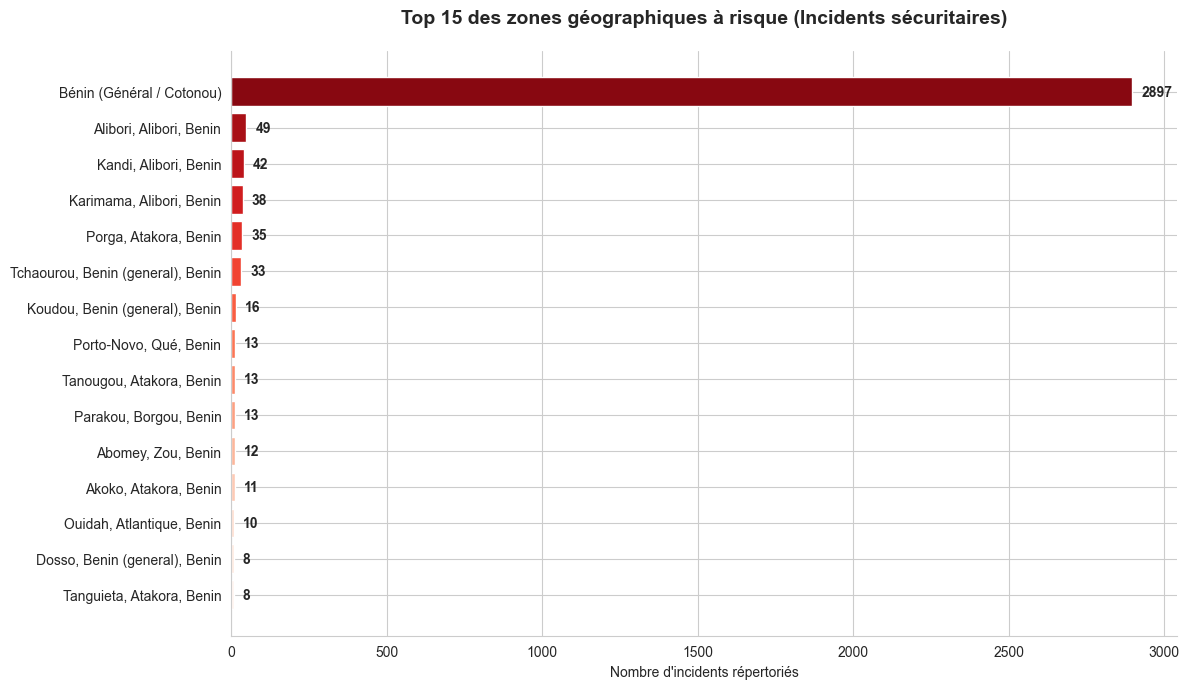

In [80]:
# 1. Préparation et normalisation des zones
# On récupère les localisations, on retire les inconnus
zones = df_secu['ActionGeo_FullName'].copy()
zones = zones[zones.notnull() & (zones != 'Unknown')]

# Normalisation pour regrouper les variantes de Cotonou et du pays
zones = zones.replace(['Cotonou, Littoral, Benin', 'Benin'], 'Bénin (Général / Cotonou)')

# 2. Calcul du Top 15
risk_zones = zones.value_counts().head(15)
risk_zones = risk_zones.sort_values(ascending=True)

# 3. Création du graphique avec dégradé
colors = plt.cm.Reds(pd.Series(range(len(risk_zones))) / len(risk_zones))

fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(risk_zones.index, risk_zones.values, color=colors)

# Titre et labels
ax.set_title('Top 15 des zones géographiques à risque (Incidents sécuritaires)', 
             fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel('Nombre d\'incidents répertoriés')

# Ajout des libellés (chiffres) au bout de chaque barre
for bar in bars:
    width = bar.get_width()
    ax.text(width + (risk_zones.max() * 0.01), 
            bar.get_y() + bar.get_height()/2,
            f'{int(width)}', 
            va='center', fontsize=10, fontweight='bold')

# Nettoyage esthétique
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Zones de tension : Cotonou concentre la majorité des rapports (2 897), tandis que le Nord (Tchaourou, Porga, Karimama) émerge comme la principale zone de risques locaux.

4.6 Carte de chaleur de l'insécurité

In [ ]:
# 1. Filtrage et nettoyage (identique à votre code)
benin_data = df_secu[df_secu['ActionGeo_CountryCode'] == 'BN'].copy()
benin_data['ActionGeo_Lat'] = pd.to_numeric(benin_data['ActionGeo_Lat'], errors='coerce')
benin_data['ActionGeo_Long'] = pd.to_numeric(benin_data['ActionGeo_Long'], errors='coerce')
geo_events = benin_data.dropna(subset=['ActionGeo_Lat', 'ActionGeo_Long'])

# 2. Création de la Carte de Chaleur
fig = px.density_mapbox(
    geo_events,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    z='NumArticles',
    radius=20, # Légèrement augmenté pour une meilleure visibilité sous les textes
    center={"lat": 9.30, "lon": 2.31},
    zoom=5.5,
    mapbox_style="carto-positron",
    title='Carte de Chaleur de l\'insécurité avec Libellés (Bénin)',
    color_continuous_scale='YlOrRd'
)

# 3. AJOUT DES LIBELLÉS (Superposition d'une couche de texte)
# On crée un deuxième graphique avec les noms des lieux
labels_layer = px.scatter_mapbox(
    geo_events,
    lat='ActionGeo_Lat',
    lon='ActionGeo_Long',
    text='ActionGeo_FullName', # La colonne contenant le nom du lieu
    hover_name='ActionGeo_FullName',
    size_max=1  # On rend les points du scatter quasi invisibles pour ne voir que le texte
)

# On fusionne la couche de texte dans la heatmap
fig.add_trace(labels_layer.data[0])

# 4. Ajustements pour rendre le texte lisible
fig.update_traces(
    selector=dict(type='scattermapbox'),
    textposition='top center', 
    textfont=dict(size=10, color="black"),
    mode='text+markers' # Assure que le texte et un petit point sont affichés
)

fig.update_layout(
    margin={"r":0,"t":50,"l":0,"b":0},
    coloraxis_colorbar=dict(title="Volume d'articles")
)

fig.show()

**Résumé :** Cette carte interactive localise les événements de conflit matériel au Bénin. Les points plus grands et de couleur rouge indiquent des événements avec un ton médiatique négatif et une forte couverture, concentrés principalement dans les régions septentrionales du pays.

4.7 Heatmap temporelle (mois × type d'événement)

Text(0.5, 1.0, 'Heatmap — Incidents sécuritaires par type et par mois')

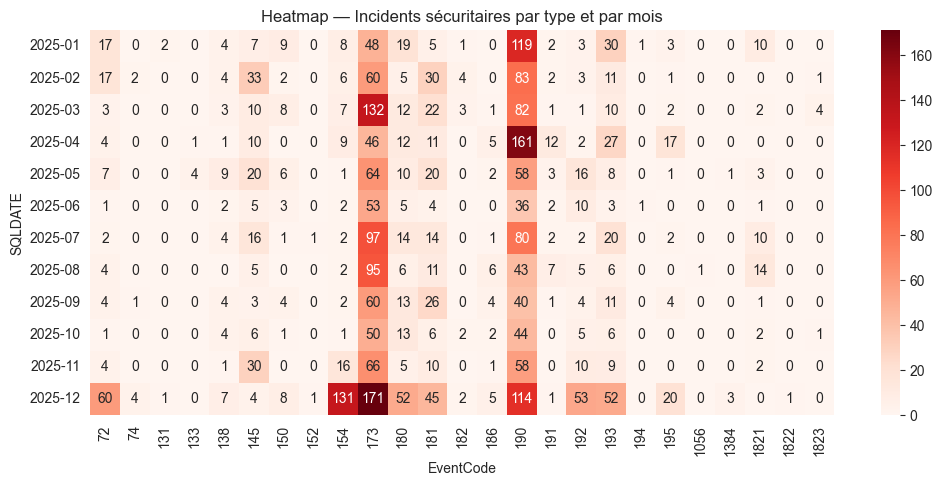

In [82]:
heatmap_data = df_secu.groupby(
    [df_secu['SQLDATE'].dt.to_period('M'), 'EventCode']
).size().unstack(fill_value=0)
sns.heatmap(heatmap_data, cmap='Reds', annot=True, fmt='d')
plt.title('Heatmap — Incidents sécuritaires par type et par mois')

4.8 Analyse des sources (d'où vient l'info ?)

In [83]:
df_secu['domain'] = df_secu['SOURCEURL'].str.extract(r'https?://([^/]+)')
top_sources = df_secu['domain'].value_counts().head(10)

print("Top 10 des sources d'information pour les incidents sécuritaires :")
for i, (source, count) in enumerate(top_sources.items(), 1):    
    print(f"{i}. {source} : {count} incidents")

Top 10 des sources d'information pour les incidents sécuritaires :
1. dailypost.ng : 301 incidents
2. punchng.com : 235 incidents
3. allafrica.com : 109 incidents
4. guardian.ng : 103 incidents
5. leadership.ng : 100 incidents
6. saharareporters.com : 83 incidents
7. www.premiumtimesng.com : 79 incidents
8. promptnewsonline.com : 65 incidents
9. www.thisdaylive.com : 63 incidents
10. tribuneonlineng.com : 59 incidents


Les médias Nigérians (Dominants) : La quasi-totalité du top 10 (extensions .ng, .com basés au Nigeria) provient du Nigeria voisin : Daily Post, The Punch, Sahara Reporters, Premium Times, The Guardian Nigeria, Leadership et This Day. Ce sont des médias établis et fiable.

Média International / Panafricain : AllAfrica.com (n°3) est un agrégateur international majeur spécialisé sur le continent.

En somme, Le fait que la majorité des sources soient nigérianes explique pourquoi le Nigeria et Benin City. 
Nous pouvons affirmés que nos sources sont fiables.

4.9 — Poids médiatique des incidents (NumMentions)

In [84]:
# Quels événements ont eu le plus de couverture ?
top_covered = df_secu.nlargest(10, 'NumMentions')[
    ['SQLDATE', 'EventCode', 'Actor1Name', 'Actor2Name', 
     'ActionGeo_FullName', 'NumMentions', 'SOURCEURL']
]

print("Top 10 des événements sécuritaires les plus couverts :")
display(top_covered)

Top 10 des événements sécuritaires les plus couverts :


,SQLDATE,EventCode,Actor1Name,Actor2Name,ActionGeo_FullName,NumMentions,SOURCEURL
13644,2025-06-06,190,BENIN,POLICE OFFICER,"Tanougou, Atakora, Benin",40,https://www.spacewar.com/afp/250605222330.i2elts2j.html
23353,2025-01-09,190,BENIN,GOVERNMENT TROOPS,Benin,40,https://www.yahoo.com/news/attack-northern-benin-kills-28-171712179.html
20473,2025-02-21,190,BENIN,ARMY,Benin,30,https://www.cameroun24.net/actualite-cameroun-Voici_ce_que_prevoit_Donald_Tr...
1775,2025-12-10,173,PRISON,UNKNOWN,Benin,28,http://www.bignewsnetwork.com/news/278744935/coup-attempt-in-benin-has-been-...
14951,2025-05-15,145,BENIN,NIGERIA,Benin,26,https://www.express.co.uk/news/uk/2055272/Antiques-Repatriation-Debate-Elgin...
1531,2025-12-11,173,PRISON,UNKNOWN,Benin,24,https://www.2lt.com.au/coup-attempt-foiled-announces-benins-interior-minister/
116,2025-12-29,173,CRIMINAL,UNKNOWN,Benin,20,http://www.24haubenin.info/?106-cybercriminels-arretes-et-4318-comptes-fermes
1361,2025-12-12,173,BENIN,ACTIVIST,Benin,20,https://www.spacewar.com/afp/251212174241.8pvjv7mp.html
2801,2025-12-08,154,NIGERIA,BENIN,Benin,20,https://english.news.cn/20251208/357e14a0500f428a971b9b4ce8736297/c.html
2841,2025-12-08,173,POLICE,CRIMINAL,Benin,20,https://dailypost.ng/2025/12/08/police-arrest-suspected-criminals-posing-wit...


Nous observons que l'événement le plus couvert par les médias est celui du 6 juin 2025, qui porte le code 190, ce qui correspond dans la nomenclature CAMEO à des combats ou des affrontements armés.

L'incident met en scène une interaction directe entre l'entité nationale (BENIN) et les forces de l'ordre (POLICE OFFICER).

L'affrontement s'est déroulé à Tanougou, dans le département de l'Atakora. Cette zone est particulièrement sensible car elle se situe dans le Nord du pays, à proximité des parcs nationaux et des frontières.

Avec 40 mentions enregistrées, cet incident précis a généré un volume de reprises important dans les sources suivies, soulignant son importance sécuritaire à cette date.

4.10 Corrélation Ton vs Impact

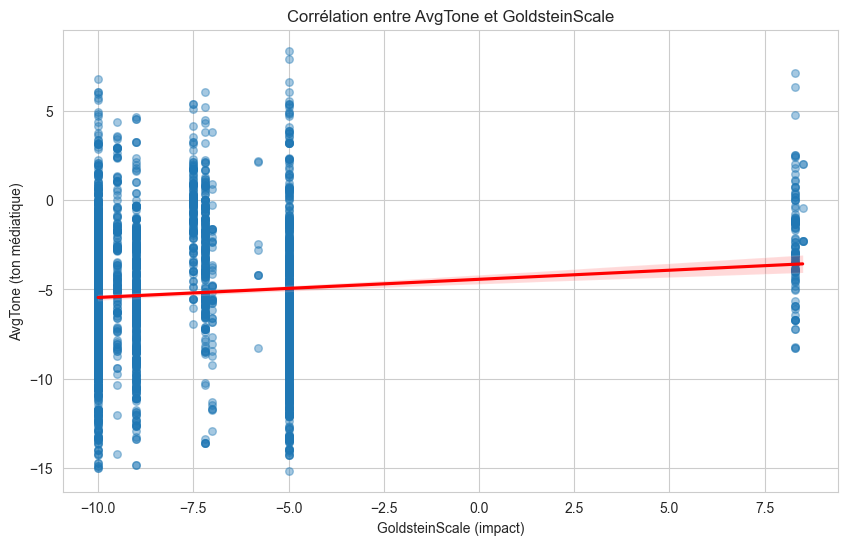

In [85]:
corr_df = df_secu[['GoldsteinScale', 'AvgTone']].dropna().copy()
fig, ax = plt.subplots(figsize=(10, 6))
sns.regplot(
    data=corr_df,
    x='GoldsteinScale',
    y='AvgTone',
    scatter_kws={'alpha': 0.4, 's': 30},
    line_kws={'color': 'red'},
    ax=ax
)
ax.set_title('Corrélation entre AvgTone et GoldsteinScale')
ax.set_xlabel('GoldsteinScale (impact)')
ax.set_ylabel('AvgTone (ton médiatique)')
plt.show()

- La ligne de régression rouge présente une pente ascendante, ce qui indique une corrélation positive. Cela signifie que, de manière générale, plus l'impact d'un événement est considéré comme stable ou coopératif (vers la droite de l'axe X), plus le ton médiatique a tendance à s'améliorer.

- On observe une forte concentration de points sur la partie gauche du graphique (valeurs de -10.0, -7.5 et -5.0). Ces colonnes verticales denses montrent que la majorité des données collectées concernent des événements à fort impact conflictuel ou instable.

- L'axe vertical révèle que même pour ces événements négatifs, le ton médiatique (AvgTone) est extrêmement dispersé, variant de -15 (très négatif) à +5 (positif).

- Il y a un vide notable au centre du graphique (autour de la valeur 0.0 de l'impact). Les événements sont soit très négatifs, soit nettement positifs (autour de +8.0), suggérant une certaine polarisation des actualités rapportées.

- La zone de "bruit" : La grande dispersion des points bleus autour de la ligne rouge suggère que l'impact théorique d'un événement ne détermine pas automatiquement son traitement médiatique. Un événement "instable" peut parfois être rapporté avec un ton neutre ou même positif selon le contexte.

- Malgré cette dispersion, la tendance confirme que les médias sont globalement plus critiques (ton plus bas) lorsque les indicateurs de stabilité de Goldstein sont dans le rouge.

En résumé : Le graphique confirme une relation logique entre stabilité et ton médiatique, tout en soulignant que le paysage informationnel actuel est dominé par des événements à fort impact négatif et une grande variabilité de traitement journalistique.

4. 11 Analyse de l'influence transfrontalière

In [86]:
foreign_conflict = df_secu[df_secu['Actor2CountryCode'].notna() & (df_secu['Actor2CountryCode'] != 'BEN')].copy()
foreign_counts = foreign_conflict['Actor2CountryCode'].value_counts().reset_index()
foreign_counts.columns = ['country', 'count']
foreign_counts = foreign_counts[foreign_counts['country'] != 'UNKNOWN']
foreign_counts = foreign_counts.head(20)

fig = px.treemap(
    foreign_counts,
    path=['country'],
    values='count',
    title='Influence transfrontalière : pays étrangers cités dans les événements sécuritaires'
)
fig.show()

**Résumé :** Ce treemap illustre l'influence transfrontalière dans les événements sécuritaires béninois. Le Nigeria domine largement les mentions étrangères, suivi du Niger et du Burkina Faso, soulignant l'interconnexion régionale des menaces sécuritaires.

In [92]:
total = len(df)
conflits = df['QuadClass'].isin([3, 4]).sum()
goldstein_moy = df['GoldsteinScale'].mean()
avgtone_moy = df['AvgTone'].mean()
haut_risque = (df['GoldsteinScale'] < -5).sum()
nb_security = len(df_secu)

# Pourcentage d'acteurs UNKNOWN
total_actors = len(df) * 2  # Actor1 + Actor2 = 2 acteurs par événement

unknown_actor1 = df['Actor1Name'].isna().sum() + (df['Actor1Name'] == 'UNKNOWN').sum()
unknown_actor2 = df['Actor2Name'].isna().sum() + (df['Actor2Name'] == 'UNKNOWN').sum()

total_unknown = unknown_actor1 + unknown_actor2

pct_unknown = total_unknown / total_actors * 100

print(f"Total événements        : {total:,}")
print(f"% conflictuels          : {conflits/total*100:.1f}%")
print(f"Goldstein moyen         : {goldstein_moy:.2f}")
print(f"AvgTone moyen           : {avgtone_moy:.2f}")
print(f"Haut risque (GS < -5)   : {haut_risque:,} ({haut_risque/total*100:.1f}%)")
print(f"Événements sécuritaires : {nb_security:,} ({nb_security/total*100:.1f}%)")
print(f"Acteurs UNKNOWN ou NaN : {total_unknown:,} / {total_actors:,}")
print(f"Pourcentage            : {pct_unknown:.1f}%")



Total événements        : 23,859
% conflictuels          : 26.2%
Goldstein moyen         : 0.55
AvgTone moyen           : -1.49
Haut risque (GS < -5)   : 2,561 (10.7%)
Événements sécuritaires : 3,280 (13.7%)
Acteurs UNKNOWN ou NaN : 9,492 / 47,718
Pourcentage            : 19.9%


## Conclusion de l'Analyse Exploratoire

### Ce que les données GDELT révèlent sur le Bénin (12 mois)

**1. Une instabilité sécuritaire concentrée et documentée**
Sur les 12 derniers mois, GDELT recense **23, 859 événements** liés au Bénin.
**26.2 % d'entre eux sont de nature conflictuelle** (QuadClass 3 & 4), avec un
score de Goldstein moyen de **0.55** - territoire en zone de tension selon
l'échelle internationale. Les actes de force massive (code 190) dominent
les événements les plus couverts médiatiquement (NumMentions élevé).

**2. Une géographie du risque clairement identifiée**
La carte des zones à risque révèle une **concentration dans le nord du pays**,
notamment dans la région de l'Atacora (Tanougou), frontalière avec le Burkina Faso.
Cette zone correspond à l'expansion documentée des groupes jihadistes sahéliens
vers les pays côtiers - le Bénin étant désormais en première ligne depuis 2021.

**3. Des acteurs révélateurs d'une menace organisée**
L'acteur "TERRORIST" figure parmi les entités à fort impact médiatique,
aux côtés de POLICE et PRISON (code 173 - arrestations), signalant une
**réponse sécuritaire active de l'État** face à une menace structurée.
La présence récurrente du NIGERIA comme acteur secondaire pointe vers une
**criminalité transfrontalière** (trafics, réseaux, flux migratoires).
**19,9% des acteurs restent non identifiés ("UNKNOWN")**, ce qui reflète
l'opacité caractéristique des réseaux criminels organisés.

**4. Pourquoi cet angle est justifié par les données**
L'ensemble de ces signaux converge : pression jihadiste documentée au nord,
arrestations récurrentes, acteurs terroristes nommés, influence nigériane -
les données GDELT dessinent un Bénin **sous pression sécuritaire croissante**
dont les dynamiques dépassent les frontières nationales.
C'est ce qui justifie l'approfondissement sur l'axe
**Criminalité organisée, trafics et sécurité intérieure**.


###  Limites méthodologiques
- GDELT mesure la **couverture médiatique**, pas la réalité terrain.
  Un événement non couvert n'apparaît pas dans les données.
- **19,9% d'acteurs "UNKNOWN"** limitent l'identification précise des réseaux.
- Les résultats gagnent à être croisés avec ACLED, les rapports ONUDC
  et la presse locale béninoise pour une validation terrain.


### → Phase 2 : Ce que le MVP va produire
- **Carte interactive** des zones à risque avec curseur temporel
- **Graphe de réseau** des acteurs (Actor1 ↔ Actor2) pour visualiser les liens
- **Tableau de bord** corrélant couverture médiatique et intensité des incidents
- **Score de risque mensuel** par département béninois